In [22]:
# =====================================================
# ANALYSE EXPLORATOIRE - HÔPITAL GOMA 2025
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [5]:
# 1. CHARGEMENT DONNÉES
print("Chargement dataset Healthcare Goma...")
df = pd.read_csv("healthcare_prediction_dataset.csv")
df.head()

Chargement dataset Healthcare Goma...


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
# 2. INFO GÉNÉRALE
print("STRUCTURE DONNÉES")
print(df.info())
print("\n STATISTIQUES DESCRIPTIVES")
print(df.describe())
print("\n" + "="*50)

STRUCTURE DONNÉES
<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  str    
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  str    
 3   Blood Type          55500 non-null  str    
 4   Medical Condition   55500 non-null  str    
 5   Date of Admission   55500 non-null  str    
 6   Doctor              55500 non-null  str    
 7   Hospital            55500 non-null  str    
 8   Insurance Provider  55500 non-null  str    
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  str    
 12  Discharge Date      55500 non-null  str    
 13  Medication          55500 non-null  str    
 14  Test Results        55500 non-null  str    
dtypes: float64(1), int64(2), str(12)
memory usage:

In [7]:
# 3. QUALITÉ DONNÉES (Nettoyage)
print("VÉRIFICATION PROBLÈMES")
print("Valeurs manquantes:", df.isnull().sum())
print("Duplicatas:", df.duplicated().sum())

VÉRIFICATION PROBLÈMES
Valeurs manquantes: Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
dtype: int64
Duplicatas: 534


In [8]:
# Nettoyage rapide
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
print(f"Après nettoyage: {df_clean.shape}")

Après nettoyage: (54966, 15)


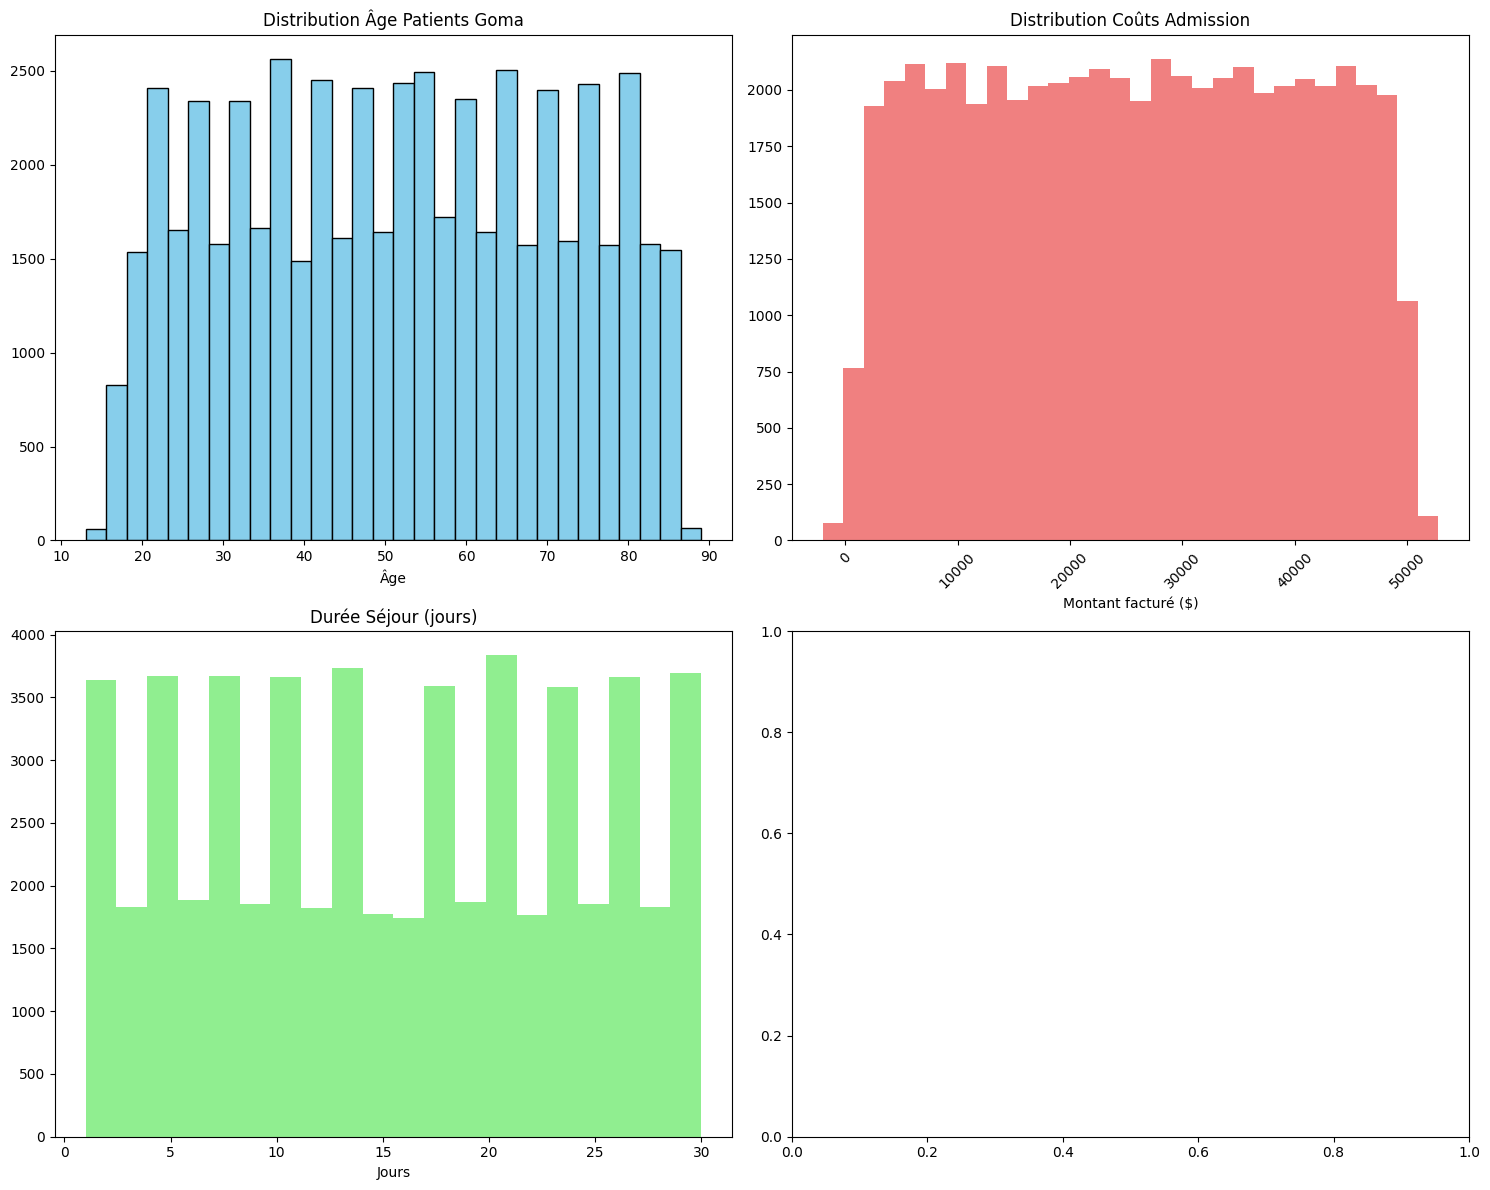

In [12]:
# 4. EDA VARIABLES NUMÉRIQUES
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Âge
axes[0,0].hist(df_clean['Age'], bins=30, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribution Âge Patients Goma')
axes[0,0].set_xlabel('Âge')

# Billed Amount
axes[0,1].hist(df_clean['Billing Amount'], bins=30, color='lightcoral')
axes[0,1].set_title('Distribution Coûts Admission')
axes[0,1].set_xlabel('Montant facturé ($)')
axes[0,1].tick_params(axis='x', rotation=45)

# Durée séjour (Discharge - Admission)
df_clean['Stay_Days'] = pd.to_datetime(df_clean['Discharge Date']) - pd.to_datetime(df_clean['Date of Admission'])
axes[1,0].hist(df_clean['Stay_Days'].dt.days, bins=20, color='lightgreen')
axes[1,0].set_title('Durée Séjour (jours)')
axes[1,0].set_xlabel('Jours')

plt.tight_layout()
plt.savefig('eda_numerique_goma.png', dpi=300, bbox_inches='tight')
plt.show()

In [17]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype          
---  ------              --------------  -----          
 0   Name                54966 non-null  str            
 1   Age                 54966 non-null  int64          
 2   Gender              54966 non-null  str            
 3   Blood Type          54966 non-null  str            
 4   Medical Condition   54966 non-null  str            
 5   Date of Admission   54966 non-null  str            
 6   Doctor              54966 non-null  str            
 7   Hospital            54966 non-null  str            
 8   Insurance Provider  54966 non-null  str            
 9   Billing Amount      54966 non-null  float64        
 10  Room Number         54966 non-null  int64          
 11  Admission Type      54966 non-null  str            
 12  Discharge Date      54966 non-null  str            
 13  Medication          54966 non-null  str        

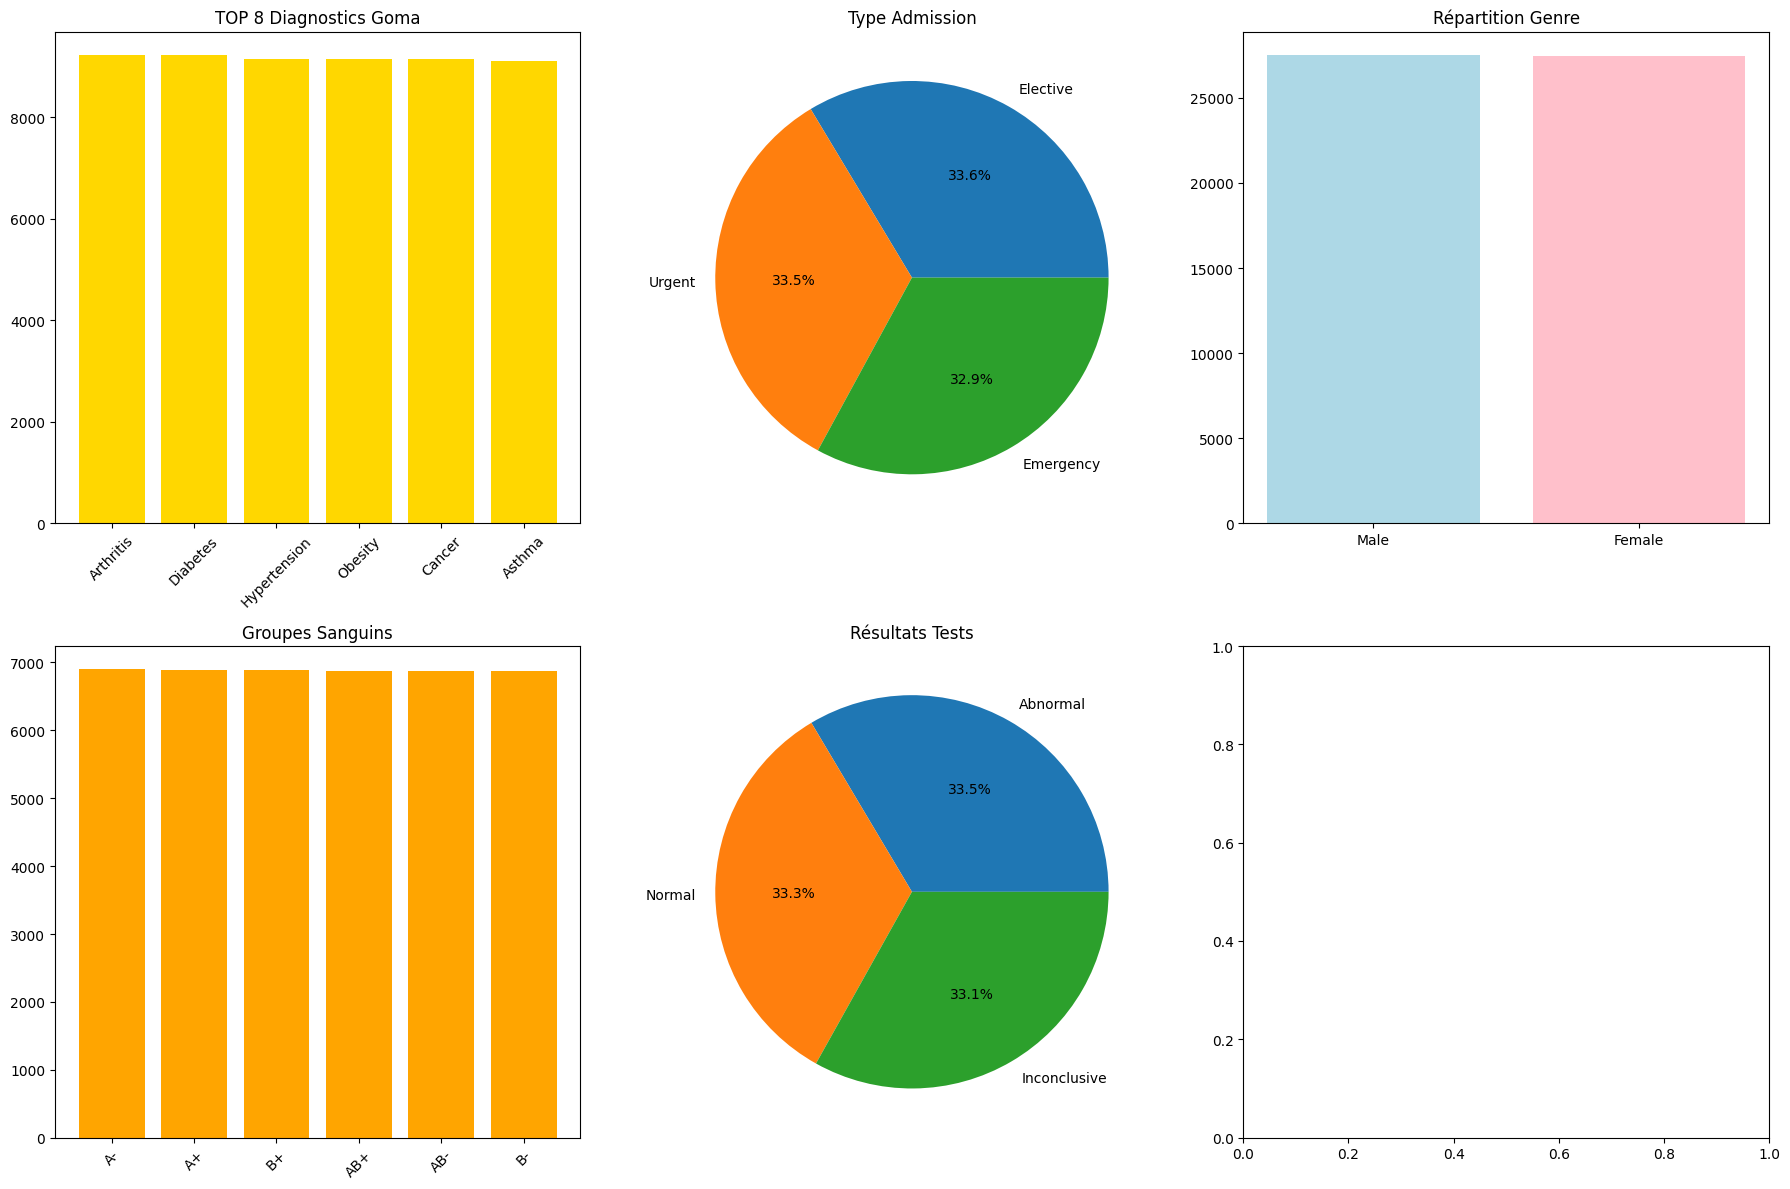

In [18]:
#5. EDA VARIABLES CATEGORIQUES
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Top Diagnostics
top_diag = df_clean['Medical Condition'].value_counts().head(8)
axes[0,0].bar(top_diag.index, top_diag.values, color='gold')
axes[0,0].set_title('TOP Diagnostics')
axes[0,0].tick_params(axis='x', rotation=45)

# Type Admission
admission = df_clean['Admission Type'].value_counts()
axes[0,1].pie(admission.values, labels=admission.index, autopct='%1.1f%%')
axes[0,1].set_title('Type Admission')

# Gender
gender = df_clean['Gender'].value_counts()
axes[0,2].bar(gender.index, gender.values, color=['lightblue', 'pink'])
axes[0,2].set_title('Répartition Genre')

# Blood Type
blood = df_clean['Blood Type'].value_counts().head(6)
axes[1,0].bar(blood.index, blood.values, color='orange')
axes[1,0].set_title('Groupes Sanguins')
axes[1,0].tick_params(axis='x', rotation=45)

# Test Outcome
test = df_clean['Test Results'].value_counts()
axes[1,1].pie(test.values, labels=test.index, autopct='%1.1f%%')
axes[1,1].set_title('Résultats Tests')

plt.tight_layout()
plt.savefig('eda_categorique_goma.png', dpi=300, bbox_inches='tight')
plt.show()


 MATRICE CORRÉLATIONS


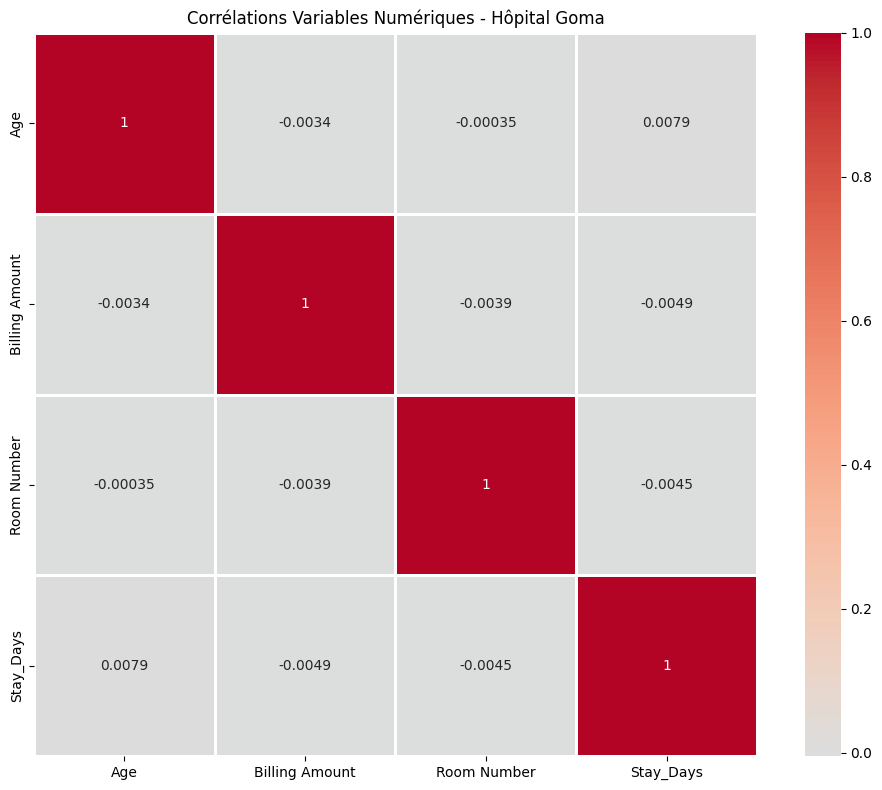

In [23]:
# 6. CORRÉLATIONS (numériques seulement)
print("\n MATRICE CORRÉLATIONS")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1)
plt.title('Corrélations Variables Numériques - Hôpital Goma')
plt.tight_layout()
plt.savefig('correlation_heatmap_goma.png', dpi=300)
plt.show()